In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl

In [7]:
coarsen_first = xr.open_dataarray("/scratch/nf33/ts1181/coarsen_first.nc")
coarsen_last = xr.open_dataarray("/scratch/nf33/ts1181/coarsen_last.nc")
diff = coarsen_first - coarsen_last

Text(0.5, 0.98, 'Wind drought probability (coarsen-first)')

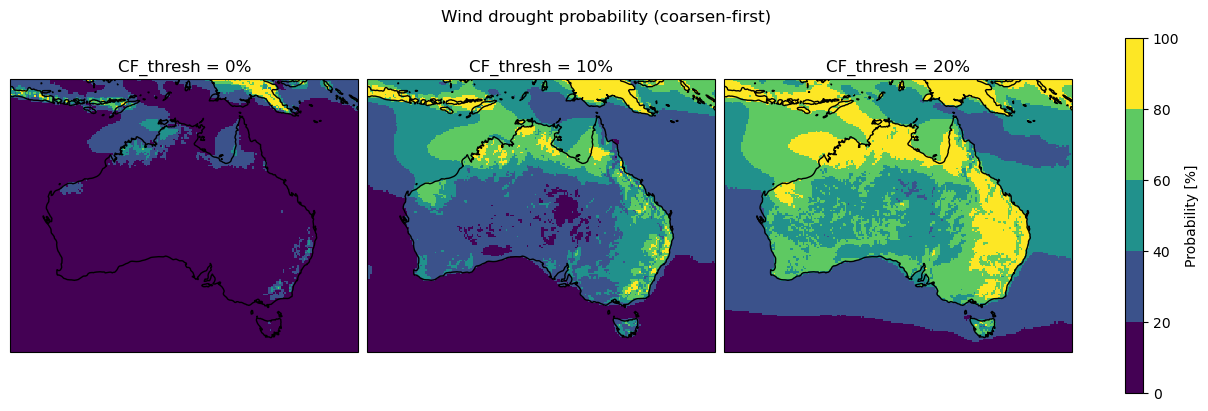

In [58]:
fig, axs = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for i, ax in enumerate(axs):
    da = coarsen_first.isel({"thresh": i})
    mesh = ax.pcolormesh(
        da["lon"],
        da["lat"],
        da * 1e2,
        cmap=mpl.colormaps["viridis"].resampled(5),
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=100,
    )
    ax.coastlines()
    ax.set_title(f"CF_thresh = {da["thresh"].item()*1e2:.0f}%")

fig.colorbar(mesh, ax=axs, label="Probability [%]")
fig.suptitle("Wind drought probability (coarsen-first)")

Text(0.5, 0.98, 'Wind drought probability difference (coarsen-first minus coarsen-last)')

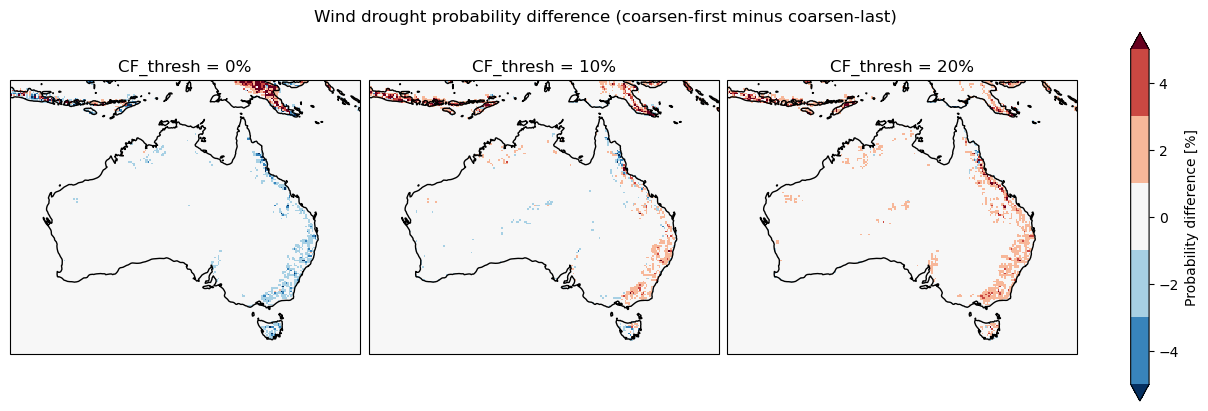

In [ ]:
fig, axs = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()},
)
colors = mpl.colormaps["RdBu_r"].resampled(7)(range(7))
cmap = mpl.colors.ListedColormap(colors[1:-1]).with_extremes(
    under=colors[0], over=colors[-1]
)

for i, ax in enumerate(axs):
    da = diff.isel({"thresh": i})
    mesh = ax.pcolormesh(
        da["lon"],
        da["lat"],
        da * 1e2,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=-5,
        vmax=5,
    )
    ax.coastlines()
    ax.set_title(f"CF_thresh = {da["thresh"].item()*1e2:.0f}%")

fig.colorbar(mesh, ax=axs, extend="both", label="Probability difference [%]")
fig.suptitle("Wind drought probability difference (coarsen-first minus coarsen-last)")

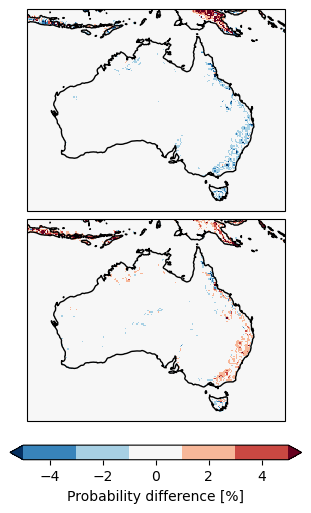

In [65]:
fig, axs = plt.subplots(
    2,
    1,
    figsize=(3, 5),
    sharex=True,
    sharey=True,
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()},
)
colors = mpl.colormaps["RdBu_r"].resampled(7)(range(7))
cmap = mpl.colors.ListedColormap(colors[1:-1]).with_extremes(
    under=colors[0], over=colors[-1]
)

for i, ax in enumerate(axs):
    da = diff.isel({"thresh": i})
    mesh = ax.pcolormesh(
        da["lon"],
        da["lat"],
        da * 1e2,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=-5,
        vmax=5,
    )
    ax.coastlines()

fig.colorbar(
    mesh,
    ax=axs,
    extend="both",
    label="Probability difference [%]",
    orientation="horizontal",
)
fig.savefig("/g/data/nf33/ts1181/GC26/ts1181/figure.png", dpi=150)